In [10]:
# -*- coding: utf-8 -*-
"""
Created on 2026

@author: Carles-Bou
"""
Adjust import paths if needed
'''
import os
import sys

#print(os.getcwd())

sys.path.insert(0, os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.insert(0, os.path.dirname(os.getcwd()))

In [11]:
'''
Import libraries
'''
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

from circle_dataset import get_circle_dataset
from circle_model   import get_circle_model 

from utils.face_torch  import FNNModule
from utils.face_torch  import count_configurations
from utils.gface_torch import get_rules

from utils.set_random  import set_random_seed
from utils.graph       import ImplicitEquationPlotter
from utils.print_texts import print_bold, get_config_structure

In [ ]:
'''
Set model ininitalization variables
'''

num_inputs = 2
num_outputs = 2
normalized_range = ([0.0, 1.0], [0.0, 1.0])
r_circle = 0.50

# Test Accuracy 0.9892
hidden_struct = [4,4]
epochs = 10000 
lr = 0.001
random_seed = 291
r_circle = 0.50

# Set seed for random number generators
set_random_seed(random_seed)

In [ ]:
'''
Load Circle dataset (generate it if it does not exist)
'''

X_train, y_train_categorical, y_train, \
    X_test, y_test_categorical, y_test = get_circle_dataset(num_inputs, random_seed, r_circle=r_circle) 

train_dataset = TensorDataset(X_train, y_train_categorical)
train_loader = DataLoader(train_dataset, batch_size=32)

In [ ]:
'''
Load Model (generate it if it does not exist)
'''

model = get_circle_model(num_inputs, num_outputs, hidden_struct, \
                         epochs, random_seed, lr, \
                         X_train, y_train, train_loader, r_circle=r_circle)

Using pretrained classification model weights from file models/circle_inputs_2_hidden_[4, 4]_epochs_10000_seed_291_lr_0.001_r_circle_0.5.pth


In [ ]:
'''
Get model accuracy for test dataset
'''

print('Generating predictions for test data ... ', end='')

mlp_predictions = model(X_test).detach().numpy()
y_mlp = np.argmax(mlp_predictions, axis=1)

print('OK')

test_accuracy = np.sum(y_mlp == y_test) / len(y_test)

print(f'Test data accuracy = {test_accuracy:.5f}\n')

Generating predictions for test data ... OK
Test data accuracy = 0.98700



In [ ]:
'''
Compute and display the observed Activation Regions (configurations) for a coverage dataset
'''

configs, config_samples, color_count = count_configurations(model, X_train, y_train)
#configs, config_samples, color_count = count_configurations(model, X_test, y_test)

activation_patterns = list(map(lambda x: get_config_structure([4, 4], x), configs.keys()))

print(f'#Activation Patterns: {len(activation_patterns)}\n')

print(f'Activation Patterns = {activation_patterns}\n')

#Activation Patterns: 23

Activation Patterns = ['0000-1000', '0001-1000', '0001-1100', '0010-0000', '0010-1000', '0011-0000', '0011-0001', '0011-0100', '0011-0101', '0011-1000', '0011-1100', '0011-1101', '0100-1000', '0100-1100', '0110-0000', '0110-0001', '0110-0100', '0110-0101', '0110-1000', '0110-1100', '0110-1101', '0111-0000', '0111-0001']



In [ ]:
'''
Compute the rules defined by the model for a selected Activation Pattern (config)
'''

config = '0111-0001'

config = '0110-0001'

print_bold(f'Rules for Activation Pattern [{config}]\n')


rule_texts = get_rules(model, X_train, y_train, 
                       normalized_range,
                       config_samples, config)

print_bold(rule_texts['rule_antecedents'][0])
print(rule_texts['rule_antecedents'][1])

print_bold(rule_texts['rule_consequent'][0])
print(rule_texts['rule_consequent'][1])

print_bold(rule_texts['activation_region'][0])
print(rule_texts['activation_region'][1])

print() 

 Class R (red)
  x1  >= 0
  x1 - 3.0305x2 + 0.9283 >= 0
  x1 + 1.0138x2 - 0.5143 <= 0
  x1 - 3.6208x2 + 0.3206 <= 0

 Class G (green)
  x1 - 3.0305x2 + 0.9283 >= 0
  x1 + 1.0138x2 - 0.5143 >= 0
  x1 - 3.6208x2 + 0.3206 <= 0
  x1 + 1.0138x2 - 0.6378 <= 0



  Y_r = -48.9744x1 - 49.6487x2 + 25.0459
  Y_g = 55.7079x1 + 56.4749x2 - 28.7957



  x1  >= 0
  x1 - 3.0305x2 + 0.9283 >= 0
  x1 + 1.0138x2 - 0.6378 <= 0
  x1 - 3.6208x2 + 0.3206 <= 0




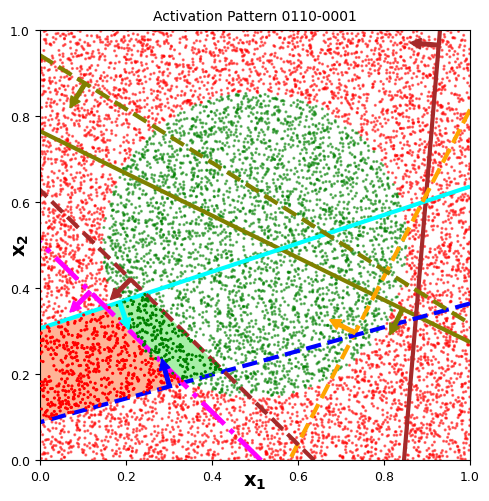

In [18]:
''' 
Plot the selected Activation Region
'''

plotter_options = {
    'configs': configs,
    'config_samples': config_samples, 
    'X': X_train, 
    'y': y_train, 
    'model': model,
    'normalized_range': normalized_range,
    'point_size': 1.5,
    'light_point_size': 1.5,
    'light_point_alpha': 0.5,
    # 'class_linewidth': 2,
    # 'neuron_linewidth': 1.6,
    'class_linewidth': 3.5,
    'neuron_linewidth': 3,
    'hidden_struct': hidden_struct,
    'arrow_length': 0.4,
    'arrow_head_size': 0.15,
}

plotter = ImplicitEquationPlotter(**plotter_options)

plotter.show(config)